# Geospatial Streaming Analytics with Stratified Sampling

This notebook demonstrates:
* **Spark Structured Streaming** with tumbling windows (no watermarks)
* **Geohash-based stratified sampling** for spatial data reduction
* **Spatial joins** using geopandas and shapely for point-in-polygon operations
* **Accuracy comparison** between full streaming data and sampled data using RMSE and MAPE

## Configuration
* **Sampling Fraction**: 80% per geohash stratum
* **Geohash Precision**: 7 (approximately 153m × 153m cells)
* **Window Duration**: 10 seconds (tumbling windows)
* **Dataset**: Chicago air quality sensor data (129,531 records)
* **Neighborhoods**: 98 Chicago neighborhoods from GeoJSON

## Cell 1: Streaming Pipeline with Geohash Stratified Sampling

### What This Cell Does:

**1. Setup & Configuration**
* Defines schema for air quality sensor data (PM2.5, temperature, humidity, etc.)
* Configures sampling parameters and window duration
* Prepares streaming directory and checkpoint locations

**2. Load Geospatial Data**
* Loads Chicago neighborhood boundaries from GeoJSON using geopandas
* Broadcasts neighborhood geometries to all Spark workers for efficient spatial joins

**3. Define UDFs**
* `geohash_udf`: Generates geohash codes (precision 7) for each sensor location
* `find_neighborhood_udf`: Performs point-in-polygon check using shapely to find which neighborhood contains each sensor reading

**4. Streaming Path (Full Data)**
* Reads CSV as a **Spark Structured Stream**
* Adds geohash and neighborhood columns using UDFs
* Aggregates by **10-second tumbling windows** and neighborhood (NO watermark)
* Writes results to in-memory table `full_data_results`
* Polls until streaming query processes data (up to 60 seconds)

**5. Batch Path (Sampled Data)**
* Reads same CSV as **batch** (required for sampling)
* Generates geohash for each record
* Performs **stratified sampling by geohash** (80% from each geohash cell)
* Applies same spatial join and window aggregation as streaming path

**6. Comparison**
* Joins full streaming results with sampled batch results
* Calculates error metrics: squared error and absolute percentage error
* Groups by neighborhood to compute average PM2.5 for full vs sampled data
* Displays detailed comparison and neighborhood-level aggregations

**7. Cleanup**
* Stops the streaming query

### Key Outputs:
* `comparison`: Window-level comparison of full vs sampled aggregations
* `neighborhood_avg`: Neighborhood-level PM2.5 averages for full and sampled data

In [33]:
import os
print(os.environ['PYTHONPATH'])

/opt/bitnami/spark/python/lib/py4j-0.10.9.5-src.zip:/opt/bitnami/spark/python/:


In [34]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install geopandas geohash2 DBUtils



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [35]:
from pyspark.sql import SparkSession

#def get_dbutils(spark):
#        try:
#            from pyspark.dbutils import DBUtils
#            dbutils = DBUtils(spark)
#        except ImportError:
#            import IPython
#            dbutils = IPython.get_ipython().user_ns["dbutils"]
#        return dbutils

spark: SparkSession = SparkSession.builder.appName(
    "air_qualy").getOrCreate()

# set log level to WARN
spark.sparkContext.setLogLevel("WARN")

#dbutils = get_dbutils(spark)
#import dbutils

In [36]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, TimestampType, IntegerType
from pyspark.sql.functions import col, window, udf
from pyspark.sql import functions as F
import geopandas as gpd
from shapely.geometry import Point
import geohash2
import time
import os
import shutil

# Configuration
SAMPLING_FRACTION = 0.8  # Sample 30% from each geohash
GEOHASH_PRECISION = 6
WINDOW_DURATION = "10 seconds"  # Tumbling window size

# Define schema
schema = StructType([
    StructField("City", StringType(), True),
    StructField("DeviceId", StringType(), True),
    StructField("LocationName", StringType(), True),
    StructField("Latitude", DoubleType(), True),
    StructField("Longitude", DoubleType(), True),
    StructField("ReadingDateTimeUTC", TimestampType(), True),
    StructField("PM25", DoubleType(), True),
    StructField("CalibratedPM25", DoubleType(), True),
    StructField("CalibratedO3", DoubleType(), True),
    StructField("CalibratedNO2", DoubleType(), True),
    StructField("CO", DoubleType(), True),
    StructField("Temperature", DoubleType(), True),
    StructField("Humidity", DoubleType(), True),
    StructField("BatteryLevel", IntegerType(), True),
    StructField("PercentBattery", DoubleType(), True),
    StructField("CellSignal", StringType(), True)
])

schemaEdge = StructType([
    StructField("City", StringType(), True),
    StructField("DeviceId", StringType(), True),
    StructField("LocationName", StringType(), True),
    StructField("Latitude", DoubleType(), True),
    StructField("Longitude", DoubleType(), True),
    StructField("ReadingDateTimeUTC", TimestampType(), True),
    StructField("PM25", DoubleType(), True),
    StructField("CalibratedPM25", DoubleType(), True),
    StructField("CalibratedO3", DoubleType(), True),
    StructField("CalibratedNO2", DoubleType(), True),
    StructField("CO", DoubleType(), True),
    StructField("Temperature", DoubleType(), True),
    StructField("Humidity", DoubleType(), True),
    StructField("BatteryLevel", IntegerType(), True),
    StructField("PercentBattery", DoubleType(), True),
    StructField("CellSignal", StringType(), True),
    StructField("geohash", StringType(), True),
    StructField("neighborhood", StringType(), True)
])

print(f"Configuration:")
print(f"  Sampling Fraction: {SAMPLING_FRACTION}")
print(f"  Geohash Precision: {GEOHASH_PRECISION}")
print(f"  Tumbling Window: {WINDOW_DURATION}")
print(f"  Watermark: None (disabled)")

start_time = time.time()

# Setup paths
csv_path = "/data/us/mobility/chicago_eclipse_data_part_1.csv"
streaming_dir = "/tmp/chicago_streaming_input"
geojson_path = "/data/us/neighborhood/chicago.geojson"
checkpoint_path = "/tmp/chicago_stream_checkpoint"

# Clean up and prepare
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
if os.path.exists(streaming_dir):
    shutil.rmtree(streaming_dir)

os.mkdir(streaming_dir)
stream_data_file = f"{streaming_dir}/data.csv" 
shutil.copyfile(csv_path, stream_data_file)

# Clean up and prepare (edge)
csv_e_path = "/csv-data/combined-08-new.csv"
streaming_e_dir = "/tmp/chicago_streaming_e_input"
checkpoint_e_path = "/tmp/chicago_stream_e_checkpoint"

# Clean up and prepare
if os.path.exists(checkpoint_e_path):
    shutil.rmtree(checkpoint_e_path)
if os.path.exists(streaming_e_dir):
    shutil.rmtree(streaming_e_dir)

os.mkdir(streaming_e_dir)
stream_data_e_file = f"{streaming_e_dir}/data.csv" 
shutil.copyfile(csv_e_path, stream_data_e_file)

load_time = time.time()
print(f"\nData setup: {load_time - start_time:.2f}s")

# Load GeoJSON neighborhoods
gdf = gpd.read_file(f"{geojson_path}")
print(f"Neighborhoods loaded: {len(gdf)}")

# Broadcast neighborhoods
neighborhood_data = [(row.geometry, row.get('name', f"Area_{i}")) 
                     for i, row in gdf.iterrows()]
neighborhoods_broadcast = spark.sparkContext.broadcast(neighborhood_data)

geojson_time = time.time()
print(f"GeoJSON loading: {geojson_time - load_time:.2f}s")

# Define geohash UDF
def generate_geohash(lat, lon):
    if lat is None or lon is None:
        return None
    return geohash2.encode(lat, lon, precision=GEOHASH_PRECISION)

geohash_udf = udf(generate_geohash, StringType())

# Spatial join UDF
def find_neighborhood(lon, lat):
    if lon is None or lat is None:
        return None
    point = Point(lon, lat)
    for geom, name in neighborhoods_broadcast.value:
        if geom.contains(point):
            return name
    return None

find_neighborhood_udf = udf(find_neighborhood, StringType())

Configuration:
  Sampling Fraction: 0.8
  Geohash Precision: 6
  Tumbling Window: 10 seconds
  Watermark: None (disabled)

Data setup: 0.16s
Neighborhoods loaded: 98
GeoJSON loading: 0.14s


In [37]:
start_time = time.time()

print("\n=== STREAMING PATH (Full Data) ===")

# Read CSV as STREAM for full data
stream_df = spark.readStream \
    .option("header", "true") \
    .schema(schema) \
    .csv(streaming_dir)

# Add geohash and neighborhood to stream
stream_with_features = stream_df \
    .withColumn("geohash", geohash_udf(col("Latitude"), col("Longitude"))) \
    .withColumn("neighborhood", find_neighborhood_udf(col("Longitude"), col("Latitude")))

# Tumbling window aggregation (NO WATERMARK)
full_data_stream = stream_with_features \
    .groupBy(
        window("ReadingDateTimeUTC", WINDOW_DURATION),
        "neighborhood"
    ).agg(
        F.avg("PM25").alias("avg_PM25_full"),
        F.avg("Temperature").alias("avg_Temperature_full"),
        F.avg("Humidity").alias("avg_Humidity_full"),
        F.count("*").alias("count_full")
    )

# Write streaming results to memory
full_query = full_data_stream.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("full_data_results") \
    .option("checkpointLocation", f"{checkpoint_path}/full") \
    .start()

print(f"Streaming query started: {full_query.id}")
print("Waiting for streaming data to process...")

# Wait for streaming query to process data (with timeout)
max_wait = 60 * 10  # max seconds
wait_interval = 1
elapsed = 0
while elapsed < max_wait:
    time.sleep(wait_interval)
    elapsed += wait_interval
    
    # Check if data has been processed
    try:
        row_count = spark.sql("SELECT COUNT(*) as cnt FROM full_data_results").collect()[0]['cnt']
        if row_count > 0:
            print(f"Streaming query processed {row_count} aggregated rows after {elapsed}s")
            break
        else:
            #print(f"  Waiting... ({elapsed}s elapsed, {row_count} rows so far)")
            pass
    except:
        print(f"  Waiting... ({elapsed}s elapsed)")

if elapsed >= max_wait:
    print(f"Warning: Streaming query did not process data within {max_wait}s")

stream_time = time.time()
print(f"Streaming setup: {stream_time - geojson_time:.2f}s")

print("\n=== BATCH PATH (Sampled Data) ===")

# Read same data as BATCH for sampling
batch_df = spark.read.format("csv").option("header", "true").schema(schema).load(f"{streaming_dir}/data.csv")

print(f"Total records: {batch_df.count()}")

# Add geohash
batch_with_geohash = batch_df.withColumn(
    "geohash", 
    geohash_udf(col("Latitude"), col("Longitude"))
)

print(f"Unique geohashes: {batch_with_geohash.select('geohash').distinct().count()}")

# Get geohash distribution for stratified sampling
geohash_counts = batch_with_geohash.groupBy("geohash").count().collect()
geohash_fractions = {row['geohash']: SAMPLING_FRACTION for row in geohash_counts if row['geohash'] is not None}

print(f"Stratified sampling with {len(geohash_fractions)} geohash strata")

# Stratified sampling by geohash
sampled_data = batch_with_geohash \
    .sampleBy("geohash", fractions=geohash_fractions, seed=42) \
    .withColumn("neighborhood", find_neighborhood_udf(col("Longitude"), col("Latitude"))) \
    .groupBy(
        window("ReadingDateTimeUTC", WINDOW_DURATION),
        "neighborhood"
    ).agg(
        F.avg("PM25").alias("avg_PM25_sampled"),
        F.avg("Temperature").alias("avg_Temperature_sampled"),
        F.avg("Humidity").alias("avg_Humidity_sampled"),
        F.count("*").alias("count_sampled")
    )

sampled_time = time.time()
print(f"Sampled data processing: {sampled_time - stream_time:.2f}s")

processing_time = time.time()
e2e = processing_time - start_time
print(f"\end-to-end latency (e2e): {e2e:.2f}s")

# --- EDGE DATA Start --- #
# stream and process edge data for comparison
start_time_edge = time.time()

stream_edge_df = spark.readStream \
    .option("header", "true") \
    .schema(schemaEdge) \
    .csv(streaming_e_dir)

full_edge_stream = stream_edge_df \
    .groupBy(
        window("ReadingDateTimeUTC", WINDOW_DURATION),
        "neighborhood"
    ).agg(
        F.avg("PM25").alias("avg_PM25_edge"),
        F.avg("Temperature").alias("avg_Temperature_edge"),
        F.avg("Humidity").alias("avg_Humidity_edge"),
        F.count("*").alias("count_edge")
    )

# Write streaming results to memory
full_edge_query = full_edge_stream.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("full_data_edge_results") \
    .option("checkpointLocation", f"{checkpoint_e_path}/full") \
    .start()

print(f"Streaming query started: {full_edge_query.id}")
print("Waiting for streaming data to process...")

# Wait for streaming query to process data (with timeout)
max_wait = 60 * 10  # max seconds
wait_interval = 1
elapsed = 0
while elapsed < max_wait:
    time.sleep(wait_interval)
    elapsed += wait_interval
    
    # Check if data has been processed
    try:
        row_count = spark.sql("SELECT COUNT(*) as cnt FROM full_data_edge_results").collect()[0]['cnt']
        if row_count > 0:
            print(f"Streaming query processed {row_count} aggregated rows after {elapsed}s")
            break
        else:
            #print(f"  Waiting... ({elapsed}s elapsed, {row_count} rows so far)")
            pass
    except:
        print(f"  Waiting... ({elapsed}s elapsed)")

if elapsed >= max_wait:
    print(f"Warning: Streaming query did not process data within {max_wait}s")

processing_time = time.time()
e2e_edge = processing_time - start_time_edge
print(f"\end-to-end latency (e2e): {e2e_edge:.2f}s")

# --- EDGE DATA End --- #

print("\n=== COMPARISON ===")

# Get streaming results from memory
full_data = spark.sql("SELECT * FROM full_data_results")
print(f"Full data aggregated rows: {full_data.count()}")
print(f"Sampled data aggregated rows: {sampled_data.count()}")
full_edge_data = spark.sql("SELECT * FROM full_data_edge_results")

# Join full and sampled results
comparison = full_data.join(
    sampled_data,
    ["window", "neighborhood"],
    "inner"
).join(
    full_edge_data,
    ["window", "neighborhood"],
    "inner"
).select(
    col("window"),
    col("neighborhood"),
    col("avg_PM25_full"),
    col("avg_PM25_sampled"),
    col("avg_PM25_edge"),
    col("avg_Temperature_full"),
    col("avg_Temperature_sampled"),
    col("avg_Temperature_edge"),
    col("avg_Humidity_full"),
    col("avg_Humidity_sampled"),
    col("avg_Humidity_edge"),
    col("count_full"),
    col("count_sampled"),
    col("count_edge"),
    # Calculate errors
    F.pow(col("avg_PM25_full") - col("avg_PM25_sampled"), 2).alias("pm25_squared_error"),
    F.pow(col("avg_PM25_full") - col("avg_PM25_edge"), 2).alias("pm25_squared_error_edge"),
    (F.abs(col("avg_PM25_full") - col("avg_PM25_sampled")) / F.abs(col("avg_PM25_full")) * 100).alias("pm25_ape"),
    (F.abs(col("avg_PM25_full") - col("avg_PM25_edge")) / F.abs(col("avg_PM25_full")) * 100).alias("pm25_ape_edge"),
    F.pow(col("avg_Temperature_full") - col("avg_Temperature_sampled"), 2).alias("temp_squared_error"),
    F.pow(col("avg_Temperature_full") - col("avg_Temperature_edge"), 2).alias("temp_squared_error_edge"),
    (F.abs(col("avg_Temperature_full") - col("avg_Temperature_sampled")) / F.abs(col("avg_Temperature_full")) * 100).alias("temp_ape"),
    (F.abs(col("avg_Temperature_full") - col("avg_Temperature_edge")) / F.abs(col("avg_Temperature_full")) * 100).alias("temp_ape_edge"),
    F.pow(col("avg_Humidity_full") - col("avg_Humidity_sampled"), 2).alias("humidity_squared_error"),
    F.pow(col("avg_Humidity_full") - col("avg_Humidity_edge"), 2).alias("humidity_squared_error_edge"),
    (F.abs(col("avg_Humidity_full") - col("avg_Humidity_sampled")) / F.abs(col("avg_Humidity_full")) * 100).alias("humidity_ape"),
    (F.abs(col("avg_Humidity_full") - col("avg_Humidity_edge")) / F.abs(col("avg_Humidity_full")) * 100).alias("humidity_ape_edge")
)

processing_time = time.time()
print(f"Comparison join: {processing_time - sampled_time:.2f}s")
print(f"Comparison result rows: {comparison.count()}")
print(f"\nTotal end-to-end latency: cloud-only {e2e:.2f}s; edge: {e2e_edge:.2f}s")
print("\nDisplaying comparison results...")

# Display comparison
display(comparison.orderBy("window", "neighborhood"))

# Group by neighborhood and calculate average PM2.5
print("\n=== AVERAGE PM2.5 BY NEIGHBORHOOD ===")
neighborhood_avg = comparison.groupBy("neighborhood").agg(
    F.avg("avg_PM25_full").alias("avg_PM25_full"),
    F.avg("avg_PM25_sampled").alias("avg_PM25_sampled"),
    F.avg("avg_PM25_sampled").alias("avg_PM25_edge"),
    F.sum("count_full").alias("total_records"),
    F.count("*").alias("num_windows")
).orderBy(F.desc("total_records"))

print("\nAverage PM2.5 per Neighborhood (Full vs Sampled):")
display(neighborhood_avg)

# Stop streaming query
full_query.stop()
full_edge_query.stop()
print("\nStreaming query stopped.")


=== STREAMING PATH (Full Data) ===
26/02/18 00:38:11 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
Streaming query started: 8c22e149-51af-4725-af8d-fcbf7b3ef2bb
Waiting for streaming data to process...


26/02/18 00:38:29 WARN TaskSetManager: Stage 26 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.
Streaming query processed 127250 aggregated rows after 13s
Streaming setup: 19.39s

=== BATCH PATH (Sampled Data) ===
Total records: 129531


Unique geohashes: 70


Stratified sampling with 70 geohash strata
Sampled data processing: 2.25s
\end-to-end latency (e2e): 20.89s
26/02/18 00:38:31 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
Streaming query started: 70baee9f-7f47-4677-a801-fad911e9a074
Waiting for streaming data to process...


26/02/18 00:38:38 WARN TaskSetManager: Stage 45 contains a task of very large size (1367 KiB). The maximum recommended task size is 1000 KiB.
Streaming query processed 101845 aggregated rows after 2s
\end-to-end latency (e2e): 6.67s

=== COMPARISON ===
26/02/18 00:38:38 WARN TaskSetManager: Stage 48 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.
Full data aggregated rows: 127250


...

Comparison result rows: 62386

Total end-to-end latency: cloud-only 20.89s; edge: 6.67s

Displaying comparison results...


DataFrame[window: struct<start:timestamp,end:timestamp>, neighborhood: string, avg_PM25_full: double, avg_PM25_sampled: double, avg_PM25_edge: double, avg_Temperature_full: double, avg_Temperature_sampled: double, avg_Temperature_edge: double, avg_Humidity_full: double, avg_Humidity_sampled: double, avg_Humidity_edge: double, count_full: bigint, count_sampled: bigint, count_edge: bigint, pm25_squared_error: double, pm25_squared_error_edge: double, pm25_ape: double, pm25_ape_edge: double, temp_squared_error: double, temp_squared_error_edge: double, temp_ape: double, temp_ape_edge: double, humidity_squared_error: double, humidity_squared_error_edge: double, humidity_ape: double, humidity_ape_edge: double]


=== AVERAGE PM2.5 BY NEIGHBORHOOD ===

Average PM2.5 per Neighborhood (Full vs Sampled):


DataFrame[neighborhood: string, avg_PM25_full: double, avg_PM25_sampled: double, avg_PM25_edge: double, total_records: bigint, num_windows: bigint]


Streaming query stopped.


## Cell 2: Calculate RMSE and MAPE for Neighborhood-Level Accuracy

### What This Cell Does:

**1. Calculate Error Metrics**
* Takes `neighborhood_avg` DataFrame from Cell 1 (contains avg PM2.5 for full and sampled data per neighborhood)
* Computes **squared error**: (full - sampled)²
* Computes **absolute percentage error**: |full - sampled| / |full| × 100

**2. Aggregate Metrics**
* **RMSE** (Root Mean Square Error): √(average of squared errors) - measures average magnitude of error
* **MAPE** (Mean Absolute Percentage Error): average of percentage errors - measures average relative error
* Counts number of neighborhoods compared

**3. Display Results**
* Prints summary metrics (RMSE, MAPE, neighborhood count)
* Shows **Top 10 neighborhoods by error** - identifies where sampling performs worst
* Shows **All neighborhoods** with detailed error breakdown

### Key Outputs:
* `neighborhood_errors`: DataFrame with error calculations per neighborhood
* `metrics`: Aggregate RMSE and MAPE values
* `neighborhood_errors_display`: Sorted by error for visualization

### Interpretation:
* **Lower RMSE** = better accuracy (closer to 0 is perfect)
* **Lower MAPE** = better relative accuracy (0% is perfect, <5% is excellent, <10% is good)

## Cell 3: Visualize Accuracy Comparison

### What This Cell Does:

**Creates 4 Visualizations:**

**1. Scatter Plot: Full vs Sampled PM2.5**
* Each point = one neighborhood
* Bubble size = number of sensor readings
* Red dashed line = perfect match (y=x)
* Shows how well sampled data matches full data

**2. Error Distribution Histogram**
* Shows distribution of percentage errors across neighborhoods
* Red vertical line = mean error (MAPE)
* Helps identify if errors are concentrated or spread out

**3. Top 10 Neighborhoods by PM2.5 Level**
* Side-by-side bars comparing full vs sampled data
* Shows neighborhoods with highest pollution
* Visual check: do high-pollution areas maintain accuracy?

**4. Top 10 Neighborhoods by Error**
* Horizontal bars showing highest errors
* Color-coded by severity:
  * 🟢 Green: <5% error (excellent)
  * 🟠 Orange: 5-10% error (good)
  * 🔴 Red: >10% error (needs attention)
* Identifies which neighborhoods have poorest sampling accuracy

**Summary Statistics:**
* Total neighborhoods analyzed
* RMSE and MAPE metrics
* Error distribution (min, max, median)
* Percentage of neighborhoods with <5% and <10% error
* Overall sampling efficiency (% data → % accuracy)

### Key Insights:
* Points close to red line = good sampling accuracy
* Tight error distribution = consistent sampling quality
* High-pollution areas should maintain accuracy for reliable analysis

In [39]:
# Calculate RMSE and MAPE for Average PM2.5 per Neighborhood (Full vs Sampled)
print("=== ACCURACY METRICS: Average PM2.5 per Neighborhood ===")
print("Comparing Full vs Sampled Data\n")

# Use the neighborhood_avg DataFrame from Cell 1
# Calculate squared error and absolute percentage error
neighborhood_errors = neighborhood_avg.withColumn(
    "squared_error",
    F.pow(col("avg_PM25_full") - col("avg_PM25_sampled"), 2)
).withColumn(
    "squared_error_edge",
    F.pow(col("avg_PM25_full") - col("avg_PM25_edge"), 2)
).withColumn(
    "absolute_pct_error",
    (F.abs(col("avg_PM25_full") - col("avg_PM25_sampled")) / F.abs(col("avg_PM25_full")) * 100)
).withColumn(
    "absolute_pct_error_edge",
    (F.abs(col("avg_PM25_full") - col("avg_PM25_edge")) / F.abs(col("avg_PM25_full")) * 100)
)

# Calculate RMSE and MAPE
metrics = neighborhood_errors.agg(
    F.sqrt(F.avg("squared_error")).alias("RMSE"),
    F.sqrt(F.avg("squared_error_edge")).alias("RMSE_edge"),
    F.avg("absolute_pct_error").alias("MAPE"),
    F.avg("absolute_pct_error_edge").alias("MAPE_edge"),
    F.count("*").alias("num_neighborhoods")
).collect()[0]

print("="*60)
print("PM2.5 Neighborhood-Level Accuracy")
print("="*60)
print(f"RMSE: {metrics['RMSE']:.4f}")
print(f"RMSE edge: {metrics['RMSE_edge']:.4f}")
print(f"MAPE: {metrics['MAPE']:.2f}%")
print(f"MAPE edge: {metrics['MAPE_edge']:.2f}%")
print(f"Number of neighborhoods: {metrics['num_neighborhoods']}")
print("="*60)

# Show detailed errors per neighborhood
print("\nDetailed Error by Neighborhood:")
neighborhood_errors_display = neighborhood_errors.select(
    "neighborhood",
    "avg_PM25_full",
    "avg_PM25_sampled",
    "avg_PM25_edge",
    "absolute_pct_error",
    "absolute_pct_error_edge",
    "total_records"
).orderBy(F.desc("absolute_pct_error"))

print("\nTop 10 Neighborhoods by Error:")
display(neighborhood_errors_display.limit(10))

print("\nAll Neighborhoods:")
display(neighborhood_errors_display)

=== ACCURACY METRICS: Average PM2.5 per Neighborhood ===
Comparing Full vs Sampled Data

26/02/18 00:39:44 WARN TaskSetManager: Stage 70 contains a task of very large size (1367 KiB). The maximum recommended task size is 1000 KiB.


26/02/18 00:40:07 WARN TaskSetManager: Stage 74 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.
PM2.5 Neighborhood-Level Accuracy
RMSE: 0.0025
RMSE edge: 0.0025
MAPE: 0.02%
MAPE edge: 0.02%
Number of neighborhoods: 34

Detailed Error by Neighborhood:

Top 10 Neighborhoods by Error:


DataFrame[neighborhood: string, avg_PM25_full: double, avg_PM25_sampled: double, avg_PM25_edge: double, absolute_pct_error: double, absolute_pct_error_edge: double, total_records: bigint]


All Neighborhoods:


DataFrame[neighborhood: string, avg_PM25_full: double, avg_PM25_sampled: double, avg_PM25_edge: double, absolute_pct_error: double, absolute_pct_error_edge: double, total_records: bigint]

In [38]:
comparison.show()

26/02/18 00:39:13 WARN TaskSetManager: Stage 65 contains a task of very large size (1367 KiB). The maximum recommended task size is 1000 KiB.


[Stage 66:================================================>         (5 + 1) / 6]

26/02/18 00:39:35 WARN TaskSetManager: Stage 67 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+---------------+-----------------+-----------------+-----------------+--------------------+-----------------------+--------------------+-----------------+--------------------+-----------------+----------+-------------+----------+------------------+-----------------------+--------+-------------+------------------+-----------------------+--------+-------------+----------------------+---------------------------+------------+-----------------+
|              window|   neighborhood|    avg_PM25_full| avg_PM25_sampled|    avg_PM25_edge|avg_Temperature_full|avg_Temperature_sampled|avg_Temperature_edge|avg_Humidity_full|avg_Humidity_sampled|avg_Humidity_edge|count_full|count_sampled|count_edge|pm25_squared_error|pm25_squared_error_edge|pm25_ape|pm25_ape_edge|temp_squared_error|temp_squared_error_edge|temp_ape|temp_ape_edge|humidity_squared_error|humidity_squared_error_edge|humidity_ape|humidity_ape_edge|
+--------------------+---------------+-----------------+------------

In [28]:
# Join full and sampled results
comparison_cloud = full_data.join(
    sampled_data,
    ["window", "neighborhood"],
    "inner"
).select(
    col("window"),
    col("neighborhood"),
    col("avg_PM25_full"),
    col("avg_PM25_sampled"),
    col("avg_Temperature_full"),
    col("avg_Temperature_sampled"),
    col("avg_Humidity_full"),
    col("avg_Humidity_sampled"),
    col("count_full"),
    col("count_sampled"),
    # Calculate errors
    F.pow(col("avg_PM25_full") - col("avg_PM25_sampled"), 2).alias("pm25_squared_error"),
    (F.abs(col("avg_PM25_full") - col("avg_PM25_sampled")) / F.abs(col("avg_PM25_full")) * 100).alias("pm25_ape"),
    F.pow(col("avg_Temperature_full") - col("avg_Temperature_sampled"), 2).alias("temp_squared_error"),
    (F.abs(col("avg_Temperature_full") - col("avg_Temperature_sampled")) / F.abs(col("avg_Temperature_full")) * 100).alias("temp_ape"),
    F.pow(col("avg_Humidity_full") - col("avg_Humidity_sampled"), 2).alias("humidity_squared_error"),
    (F.abs(col("avg_Humidity_full") - col("avg_Humidity_sampled")) / F.abs(col("avg_Humidity_full")) * 100).alias("humidity_ape")
)
comparison_cloud.show()

[Stage 98:================================================>         (5 + 1) / 6]

26/02/18 00:22:33 WARN TaskSetManager: Stage 99 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+---------------+----------------+----------------+--------------------+-----------------------+-----------------+--------------------+----------+-------------+------------------+--------+------------------+--------+----------------------+------------+
|              window|   neighborhood|   avg_PM25_full|avg_PM25_sampled|avg_Temperature_full|avg_Temperature_sampled|avg_Humidity_full|avg_Humidity_sampled|count_full|count_sampled|pm25_squared_error|pm25_ape|temp_squared_error|temp_ape|humidity_squared_error|humidity_ape|
+--------------------+---------------+----------------+----------------+--------------------+-----------------------+-----------------+--------------------+----------+-------------+------------------+--------+------------------+--------+----------------------+------------+
|{2021-06-22 04:35...|Washington Park|1.88005113601685|1.88005113601685|    16.9239807128906|       16.9239807128906|  61.151123046875|     61.151123046875|         1|           

In [29]:
full_edge_data.show()

26/02/18 00:24:58 WARN TaskSetManager: Stage 102 contains a task of very large size (1445 KiB). The maximum recommended task size is 1000 KiB.
+--------------------+--------------------+----------------+--------------------+-----------------+----------+
|              window|        neighborhood|   avg_PM25_edge|avg_Temperature_edge|avg_Humidity_edge|count_edge|
+--------------------+--------------------+----------------+--------------------+-----------------+----------+
|{2021-06-25 19:04...| """Humboldt Park"""|16.1363887786865|    24.3153381347656| 82.1640014648438|         1|
|{2021-06-20 23:42...| """Humboldt Park"""|5.18475532531738|    29.7947692871094|   54.50439453125|         1|
|{2021-06-21 23:49...|"""Little Village"""|2.85935401916504|    23.0709838867188| 32.0587158203125|         1|
|{2021-07-09 08:25...|"""Little Village"""|3.97148871421814|    16.7958068847656| 77.3757934570313|         1|
|{2021-07-01 03:55...|     """Englewood"""|22.0066013336182|    22.8253173828125

In [30]:
full_data.show()

26/02/18 00:25:20 WARN TaskSetManager: Stage 103 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.
+--------------------+---------------+----------------+--------------------+-----------------+----------+
|              window|   neighborhood|   avg_PM25_full|avg_Temperature_full|avg_Humidity_full|count_full|
+--------------------+---------------+----------------+--------------------+-----------------+----------+
|{2021-06-29 05:17...|  Humboldt Park|7.95717620849609|    24.3981170654297| 83.1146240234375|         1|
|{2021-07-03 01:00...|        Douglas|2.07198143005371|    20.5529022216797| 59.1873168945313|         1|
|{2021-07-07 23:27...|      West Loop|12.2349729537964|    27.2152709960938| 62.2787475585938|         1|
|{2021-07-02 02:16...| Auburn Gresham|1.44046676158905|    18.9373779296875| 64.1342163085938|         1|
|{2021-06-25 21:00...|Washington Park|11.1568222045898|    28.2192993164063| 70.8709716796875|         1|
|{2021-07

In [27]:
# Join full and sampled results
comparison_edge = full_data.join(
    full_edge_data,
    ["window", "neighborhood"],
    "inner"
).select(
    col("window"),
    col("neighborhood"),
    col("avg_PM25_full"),
    col("avg_PM25_edge"),
    col("avg_Temperature_full"),
    col("avg_Temperature_edge"),
    col("avg_Humidity_full"),
    col("avg_Humidity_edge"),
    col("count_full"),
    col("count_edge"),
    # Calculate errors
    F.pow(col("avg_PM25_full") - col("avg_PM25_edge"), 2).alias("pm25_squared_error_edge"),
    (F.abs(col("avg_PM25_full") - col("avg_PM25_edge")) / F.abs(col("avg_PM25_full")) * 100).alias("pm25_ape_edge"),
    F.pow(col("avg_Temperature_full") - col("avg_Temperature_edge"), 2).alias("temp_squared_error_edge"),
    (F.abs(col("avg_Temperature_full") - col("avg_Temperature_edge")) / F.abs(col("avg_Temperature_full")) * 100).alias("temp_ape_edge"),
    F.pow(col("avg_Humidity_full") - col("avg_Humidity_edge"), 2).alias("humidity_squared_error_edge"),
    (F.abs(col("avg_Humidity_full") - col("avg_Humidity_edge")) / F.abs(col("avg_Humidity_full")) * 100).alias("humidity_ape_edge")
)

comparison_edge.show()

26/02/18 00:20:31 WARN TaskSetManager: Stage 94 contains a task of very large size (1445 KiB). The maximum recommended task size is 1000 KiB.
26/02/18 00:20:31 WARN TaskSetManager: Stage 95 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.
26/02/18 00:20:31 WARN TaskSetManager: Stage 96 contains a task of very large size (1706 KiB). The maximum recommended task size is 1000 KiB.
26/02/18 00:20:31 WARN TaskSetManager: Stage 97 contains a task of very large size (1708 KiB). The maximum recommended task size is 1000 KiB.
+------+------------+-------------+-------------+--------------------+--------------------+-----------------+-----------------+----------+----------+-----------------------+-------------+-----------------------+-------------+---------------------------+-----------------+
|window|neighborhood|avg_PM25_full|avg_PM25_edge|avg_Temperature_full|avg_Temperature_edge|avg_Humidity_full|avg_Humidity_edge|count_full|count_edge|pm25_square

In [25]:
print(metrics)
neighborhood_errors.show()
neighborhood_avg.show()

Row(RMSE=None, RMSE_edge=None, MAPE=None, MAPE_edge=None, num_neighborhoods=0)
26/02/18 00:17:25 WARN TaskSetManager: Stage 77 contains a task of very large size (1445 KiB). The maximum recommended task size is 1000 KiB.


26/02/18 00:17:43 WARN TaskSetManager: Stage 81 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.
+------------+-------------+----------------+-------------+-------------+-----------+-------------+------------------+------------------+-----------------------+
|neighborhood|avg_PM25_full|avg_PM25_sampled|avg_PM25_edge|total_records|num_windows|squared_error|squared_error_edge|absolute_pct_error|absolute_pct_error_edge|
+------------+-------------+----------------+-------------+-------------+-----------+-------------+------------------+------------------+-----------------------+
+------------+-------------+----------------+-------------+-------------+-----------+-------------+------------------+------------------+-----------------------+

26/02/18 00:17:44 WARN TaskSetManager: Stage 83 contains a task of very large size (1445 KiB). The maximum recommended task size is 1000 KiB.


26/02/18 00:18:03 WARN TaskSetManager: Stage 86 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.
+------------+-------------+----------------+-------------+-------------+-----------+
|neighborhood|avg_PM25_full|avg_PM25_sampled|avg_PM25_edge|total_records|num_windows|
+------------+-------------+----------------+-------------+-------------+-----------+
+------------+-------------+----------------+-------------+-------------+-----------+



In [40]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install matplotlib pandas


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Visualizing 34 neighborhoods



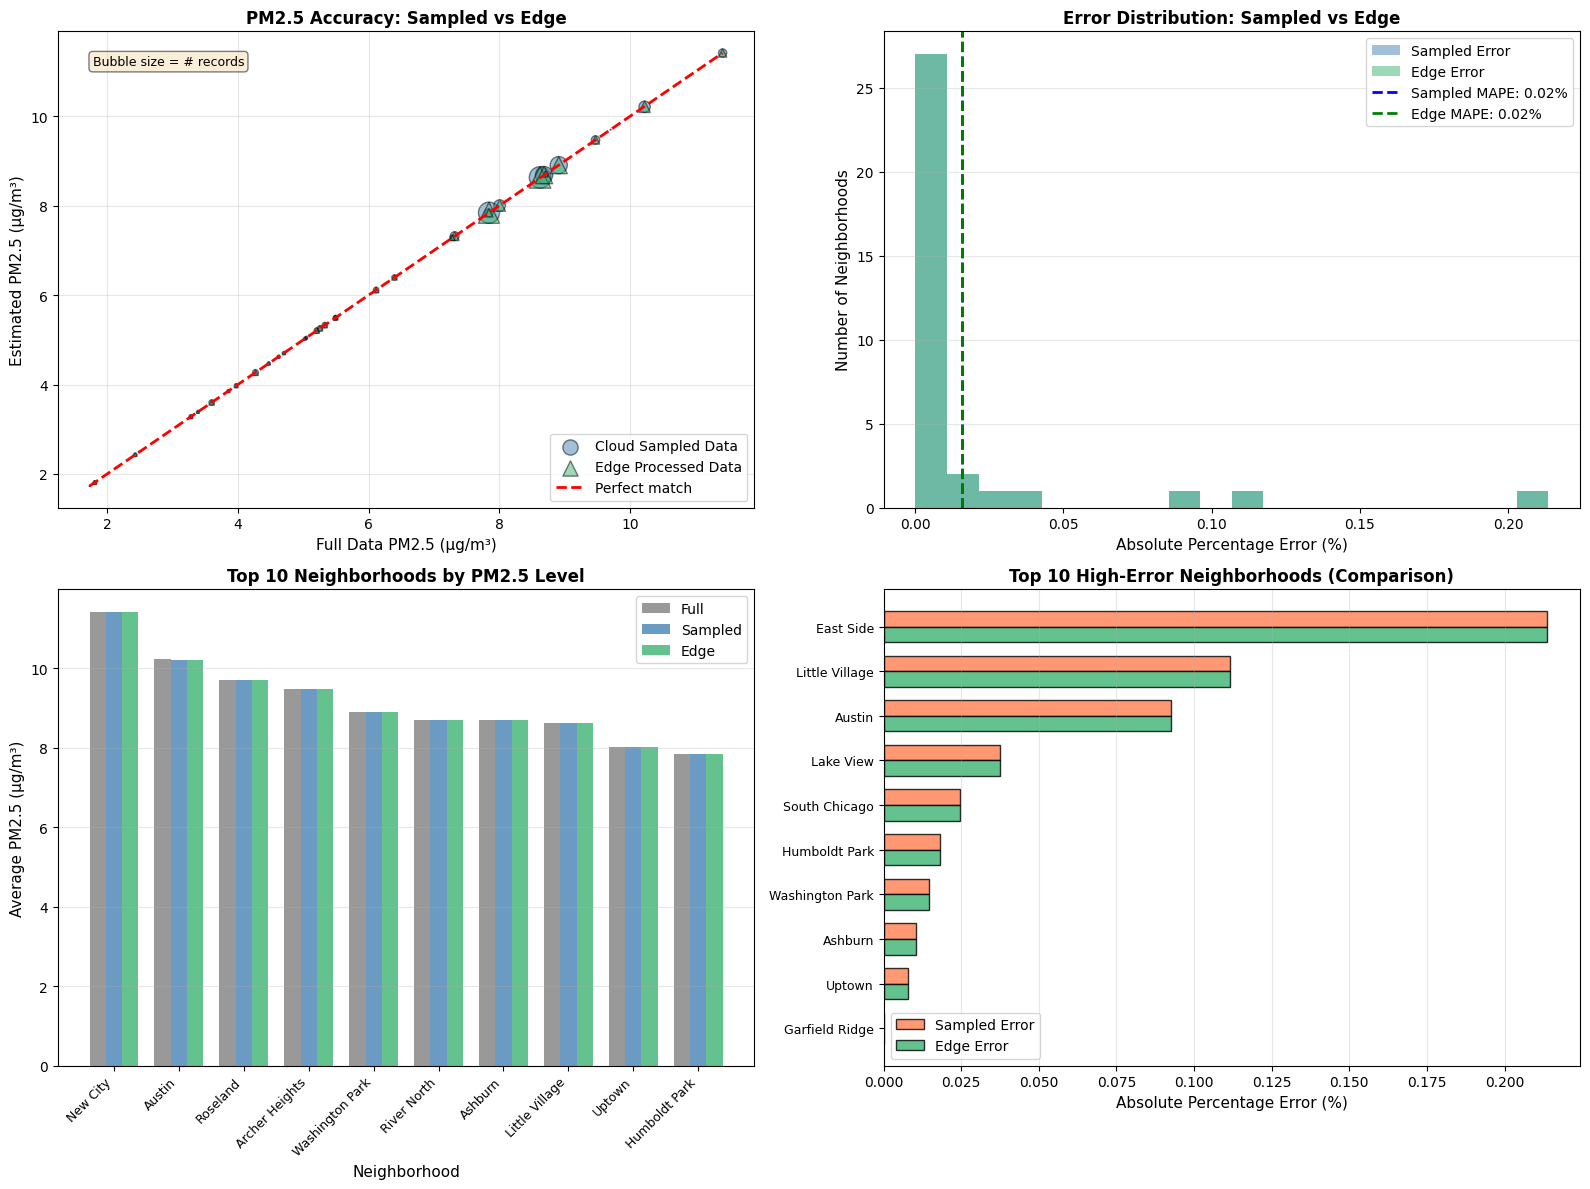


                               SUMMARY STATISTICS                               
Total Neighborhoods: 34

Metric                    | Sampled Data         | Edge Data            | Improvement    
----------------------------------------------------------------------------------------
RMSE (μg/m³)              | 0.0025               | 0.0025               | +0.0000
MAPE (%)                  | 0.02                 | 0.02                 | +0.00%

Error Distribution (Edge):
  Min Error: 0.00%
  Max Error: 0.21%
  Median Error: 0.00%

Neighborhoods with < 5% error (Edge): 34 (100.0%)
Neighborhoods with < 10% error (Edge): 34 (100.0%)


In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convert neighborhood errors to pandas for visualization
neighborhood_pd = neighborhood_errors_display.toPandas()

print(f"Visualizing {len(neighborhood_pd)} neighborhoods\n")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. PM2.5 Scatter: Full vs (Sampled & Edge) ---
ax1 = axes[0, 0]

# Plot Sampled (Blue)
ax1.scatter(neighborhood_pd['avg_PM25_full'], neighborhood_pd['avg_PM25_sampled'], 
            s=neighborhood_pd['total_records']/50, alpha=0.5, c='steelblue', 
            edgecolors='black', label='Cloud Sampled Data', marker='o')

# Plot Edge (Green)
ax1.scatter(neighborhood_pd['avg_PM25_full'], neighborhood_pd['avg_PM25_edge'], 
            s=neighborhood_pd['total_records']/50, alpha=0.5, c='mediumseagreen', 
            edgecolors='black', label='Edge Processed Data', marker='^')

# Perfect match line
# Calculate min/max across all 3 columns to set bounds correctly
all_vals = pd.concat([neighborhood_pd['avg_PM25_full'], neighborhood_pd['avg_PM25_sampled'], neighborhood_pd['avg_PM25_edge']])
min_val, max_val = all_vals.min(), all_vals.max()

ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect match')

ax1.set_xlabel('Full Data PM2.5 (μg/m³)', fontsize=11)
ax1.set_ylabel('Estimated PM2.5 (μg/m³)', fontsize=11)
ax1.set_title(f'PM2.5 Accuracy: Sampled vs Edge', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f'Bubble size = # records', transform=ax1.transAxes, 
         fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


# --- 2. Error Distribution (Histogram Comparison) ---
ax2 = axes[0, 1]

# Sampled Hist
ax2.hist(neighborhood_pd['absolute_pct_error'], bins=20, alpha=0.5, 
         color='steelblue', label='Sampled Error', density=False)

# Edge Hist
ax2.hist(neighborhood_pd['absolute_pct_error_edge'], bins=20, alpha=0.5, 
         color='mediumseagreen', label='Edge Error', density=False)

# Add Vertical Mean Lines
ax2.axvline(metrics['MAPE'], color='blue', linestyle='--', linewidth=2, label=f'Sampled MAPE: {metrics["MAPE"]:.2f}%')
ax2.axvline(metrics['MAPE_edge'], color='green', linestyle='--', linewidth=2, label=f'Edge MAPE: {metrics["MAPE_edge"]:.2f}%')

ax2.set_xlabel('Absolute Percentage Error (%)', fontsize=11)
ax2.set_ylabel('Number of Neighborhoods', fontsize=11)
ax2.set_title('Error Distribution: Sampled vs Edge', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')


# --- 3. Top 10 Neighborhoods by PM2.5 Level (Grouped Bar) ---
ax3 = axes[1, 0]
top_10 = neighborhood_pd.nlargest(10, 'avg_PM25_full')
x = np.arange(len(top_10))
width = 0.25  # Thinner bars to fit 3

ax3.bar(x - width, top_10['avg_PM25_full'], width, label='Full', alpha=0.8, color='gray')
ax3.bar(x, top_10['avg_PM25_sampled'], width, label='Sampled', alpha=0.8, color='steelblue')
ax3.bar(x + width, top_10['avg_PM25_edge'], width, label='Edge', alpha=0.8, color='mediumseagreen')

ax3.set_xlabel('Neighborhood', fontsize=11)
ax3.set_ylabel('Average PM2.5 (μg/m³)', fontsize=11)
ax3.set_title('Top 10 Neighborhoods by PM2.5 Level', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(top_10['neighborhood'], rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')


# --- 4. Top 10 Neighborhoods by Error (Side-by-Side Comparison) ---
ax4 = axes[1, 1]
# We select top 10 based on Sampled Error to see if Edge fixed them
top_errors = neighborhood_pd.nlargest(10, 'absolute_pct_error')
y = np.arange(len(top_errors))
height = 0.35

# Sampled Errors
ax4.barh(y - height/2, top_errors['absolute_pct_error'], height, label='Sampled Error', color='coral', alpha=0.8, edgecolor='black')
# Edge Errors
ax4.barh(y + height/2, top_errors['absolute_pct_error_edge'], height, label='Edge Error', color='mediumseagreen', alpha=0.8, edgecolor='black')

ax4.set_yticks(y)
ax4.set_yticklabels(top_errors['neighborhood'], fontsize=9)
ax4.set_xlabel('Absolute Percentage Error (%)', fontsize=11)
ax4.set_title('Top 10 High-Error Neighborhoods (Comparison)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis() # Highest error on top
ax4.legend(fontsize=10)

plt.tight_layout()
plt.show()

# --- Summary Statistics ---
print("\n" + "="*80)
print(f"{'SUMMARY STATISTICS':^80}")
print("="*80)
print(f"Total Neighborhoods: {len(neighborhood_pd)}")

# Create a comparison table format
print(f"\n{'Metric':<25} | {'Sampled Data':<20} | {'Edge Data':<20} | {'Improvement':<15}")
print("-" * 88)

rmse_imp = metrics['RMSE'] - metrics['RMSE_edge']
mape_imp = metrics['MAPE'] - metrics['MAPE_edge']

print(f"{'RMSE (μg/m³)':<25} | {metrics['RMSE']:<20.4f} | {metrics['RMSE_edge']:<20.4f} | {rmse_imp:+.4f}")
print(f"{'MAPE (%)':<25} | {metrics['MAPE']:<20.2f} | {metrics['MAPE_edge']:<20.2f} | {mape_imp:+.2f}%")

print("\nError Distribution (Edge):")
print(f"  Min Error: {neighborhood_pd['absolute_pct_error_edge'].min():.2f}%")
print(f"  Max Error: {neighborhood_pd['absolute_pct_error_edge'].max():.2f}%")
print(f"  Median Error: {neighborhood_pd['absolute_pct_error_edge'].median():.2f}%")

edge_u5 = (neighborhood_pd['absolute_pct_error_edge'] < 5).sum()
edge_u10 = (neighborhood_pd['absolute_pct_error_edge'] < 10).sum()

print(f"\nNeighborhoods with < 5% error (Edge): {edge_u5} ({edge_u5/len(neighborhood_pd)*100:.1f}%)")
print(f"Neighborhoods with < 10% error (Edge): {edge_u10} ({edge_u10/len(neighborhood_pd)*100:.1f}%)")
print("="*80)

In [31]:
spark.stop()